11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9245 - loss: 0.2617 - val_accuracy: 0.9576 - val_loss: 0.1357
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9664 - loss: 0.1109 - val_accuracy: 0.9643 - val_loss: 0.1178
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9759 - loss: 0.0782 - val_accuracy: 0.9679 - val_loss: 0.1086
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9817 - loss: 0.0582 - val_accuracy: 0.9726 - val_loss: 0.0949
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9855 - loss: 0.0456 - val_accuracy: 0.9726 - val_loss: 0.1025
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9877 - loss: 0.0374 - val_accuracy: 0.9752 - val_loss: 0.0904
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9894 - loss: 0.0309 - val_accuracy: 0.9758 - val_loss: 0.0923
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9923 - loss: 0.0254 - 

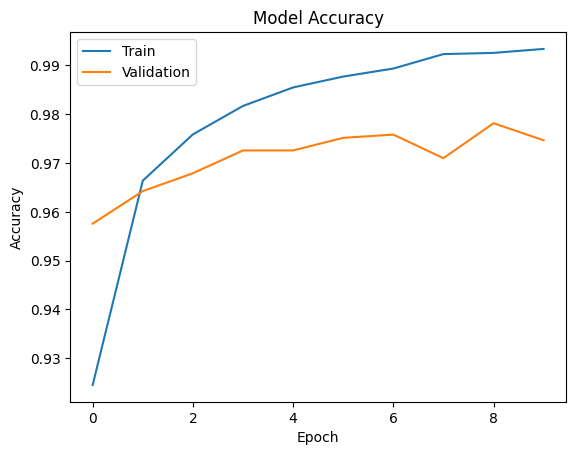

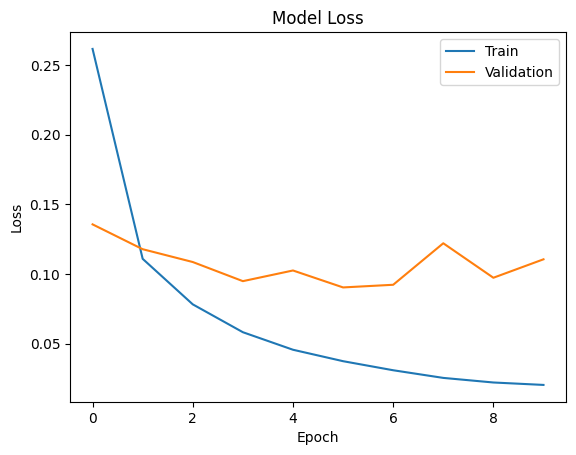

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


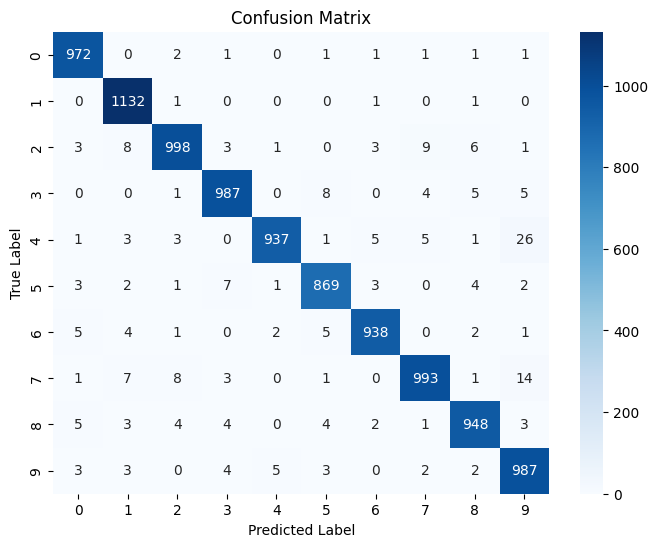

In [ ]:
# =========================================
# Experiment 7: ANN using TensorFlow/Keras
# Dataset: MNIST Handwritten Digits
# =========================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -----------------------------------------
# 1. Load Dataset
# -----------------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# -----------------------------------------
# 2. Normalize Dataset
# -----------------------------------------
x_train = x_train / 255.0
x_test = x_test / 255.0

# -----------------------------------------
# 3. Build ANN Model
# -----------------------------------------
model = Sequential()

model.add(Flatten(input_shape=(28, 28)))  # Input layer
model.add(Dense(128, activation='relu'))  # Hidden layer 1
model.add(Dense(64, activation='relu'))   # Hidden layer 2
model.add(Dense(10, activation='softmax'))  # Output layer

# -----------------------------------------
# 4. Compile Model
# -----------------------------------------
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# -----------------------------------------
# 5. Train Model
# -----------------------------------------
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

# -----------------------------------------
# 6. Evaluate Model
# -----------------------------------------
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

# -----------------------------------------
# 7. Plot Accuracy Curve
# -----------------------------------------
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# -----------------------------------------
# 8. Plot Loss Curve
# -----------------------------------------
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

# -----------------------------------------
# 9. Confusion Matrix
# -----------------------------------------
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

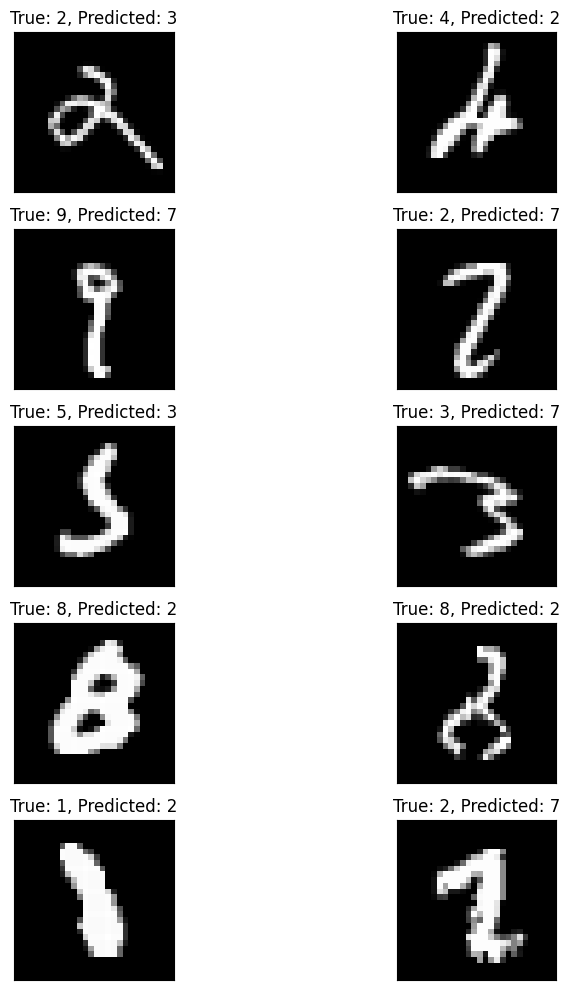

In [ ]:
misclassified_indices = np.where(y_test != y_pred_classes)[0]

plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(misclassified_indices[:10]):
    plt.subplot(5, 2, i + 1)
    plt.imshow(x_test[bad_index], cmap='gray', interpolation='none')
    plt.title(f"True: {y_test[bad_index]}, Predicted: {y_pred_classes[bad_index]}")
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()